In [3]:
# Anomaly Detection from islolation forest 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("thyroid_dataset.csv")

In [11]:
df.head(4)

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o


In [13]:
x  = df.drop("Outlier_label",axis = 1)
y = df["Outlier_label"]

In [15]:
# normalization 
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [45]:
from sklearn.ensemble import IsolationForest
clf = IsolationForest(n_estimators=200,contamination=0.0361,random_state = 42)
labels=clf.fit_predict(x_scaled)

In [46]:
from sklearn.decomposition import PCA 
pca = PCA(n_components = 2)
x_pca = pca.fit_transform(x_scaled)

Text(0, 0.5, 'PC2')

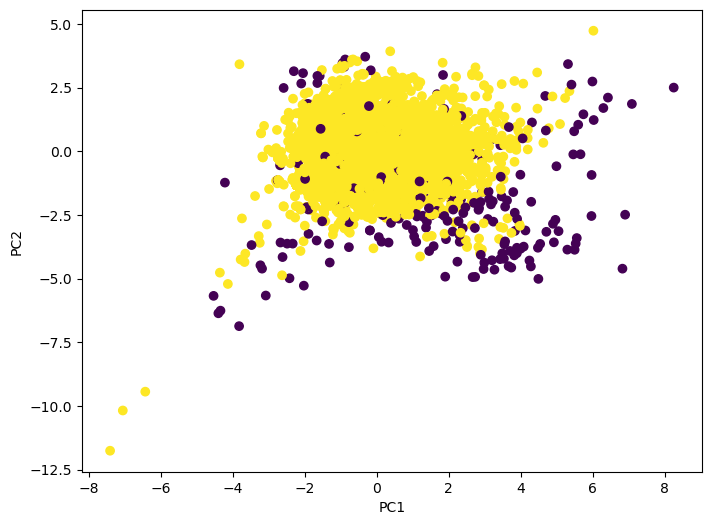

In [47]:
plt.figure(figsize=(8,6))

plt.scatter(x_pca[:,0],x_pca[:,1],c = labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [48]:
import numpy as np
outliers =np.sum(labels ==-1)
normal = np.sum(labels==1)

In [49]:
print("Your outliers are: ",outliers)
print("Your normal points are: ",normal)

Your outliers are:  250
Your normal points are:  6666


# LOF

In [62]:
from sklearn.neighbors import LocalOutlierFactor
lof=LocalOutlierFactor( contamination=0.0361)
lab = lof.fit_predict(x_scaled)

Text(0, 0.5, 'PC2')

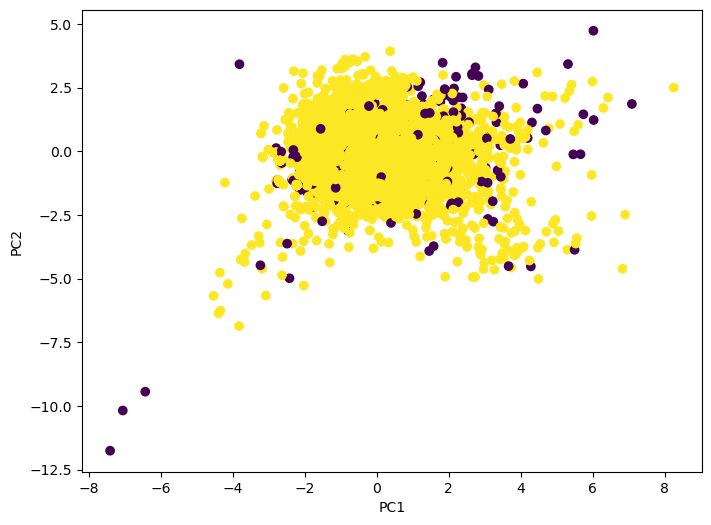

In [63]:
plt.figure(figsize=(8,6))

plt.scatter(x_pca[:,0],x_pca[:,1],c = lab)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [64]:
outliers_lof =np.sum(lab ==-1)
normal_lof = np.sum(lab==1)

In [65]:
print("Your outliers by lofare: ",outliers_lof)
print("Your normal points are: ",normal_lof)

Your outliers by lofare:  250
Your normal points are:  6666
